# Step 3: MSM construction and validation

In [88]:
data_folder = "./data/"

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx # graph visualization of MSM microstates and macrostates model



# Compute the transition COUNTS matrix C from trajectory
from deeptime.markov import TransitionCountEstimator
# Estimate the transition matrix T from C
from deeptime.markov.msm import MaximumLikelihoodMSM

---
## Construction

### Reload the trajectory, already discretized into MSM-microstates

In [2]:
kmeans_results = np.load("kmeans_results.npz")

traj = kmeans_results['traj']
centers = kmeans_results['centers']

In [5]:
simulation_length = 305 #microseconds
time_between_frames_mus = simulation_length / traj.shape[0] #microseconds
print("Time between consecutive frames (ns): ", time_between_frames_mus * 10**3)

Time between consecutive frames (ns):  0.19986356854108112


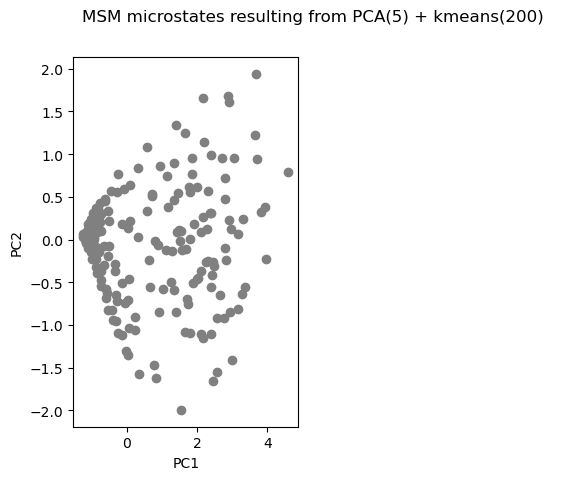

In [3]:
fig, axs = plt.subplots(nrows = 1, ncols = 2)


ax = axs[0]
for center in centers:
    ax.scatter(center[0], center[1], color = "grey")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")


ax = axs[1]
ax.set_axis_off()
## possibly, to add
# Save also the full feature trajs (after PCA) and scatterplot their cluster asignments
###


plt.suptitle("MSM microstates resulting from PCA(5) + kmeans(200)")
plt.show()

### Given a lag time $\tau$, count the transitions


$$
    C_{\tau}(i, j) = \text{n. of transitions}\quad s(t+\tau)=i \leftarrow s(t)=j
$$

Parameters to choose:
- lag time, $\tau \in \mathbb{N}$ at which to compute the counts matrix 
- the counting mode: "sample", "sliding", "sliding-effective", "effective". See [deeptime documentation](https://deeptime-ml.github.io/latest/notebooks/transition-counting.html).


In [11]:
tau_ns = 10 # nanoseconds

time_between_frames_ns = time_between_frames_mus * 10**3
n_frames_lag = tau_ns // time_between_frames_ns

print("Lag (number of frames): ", n_frames_lag)
print("Total samples: ", traj.shape[0]//n_frames_lag)

Lag (number of frames):  50.0
Total samples:  30520.0


In [ ]:
estimator = TransitionCountEstimator(
    lagtime=int(n_frames_lag),
    count_mode="sliding-effective"
)
counts = estimator.fit(traj).fetch_model()

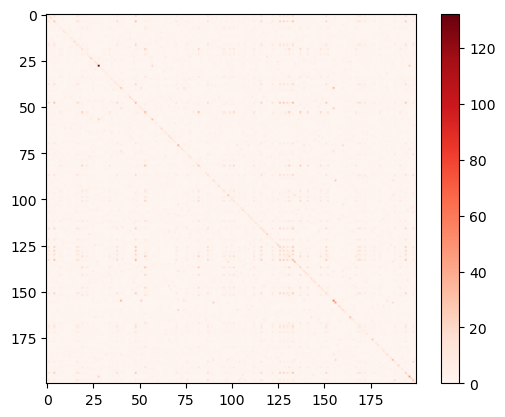

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 1)

ax = axs
im = ax.imshow(counts.count_matrix, cmap = "Reds")
fig.colorbar(im, ax = ax)

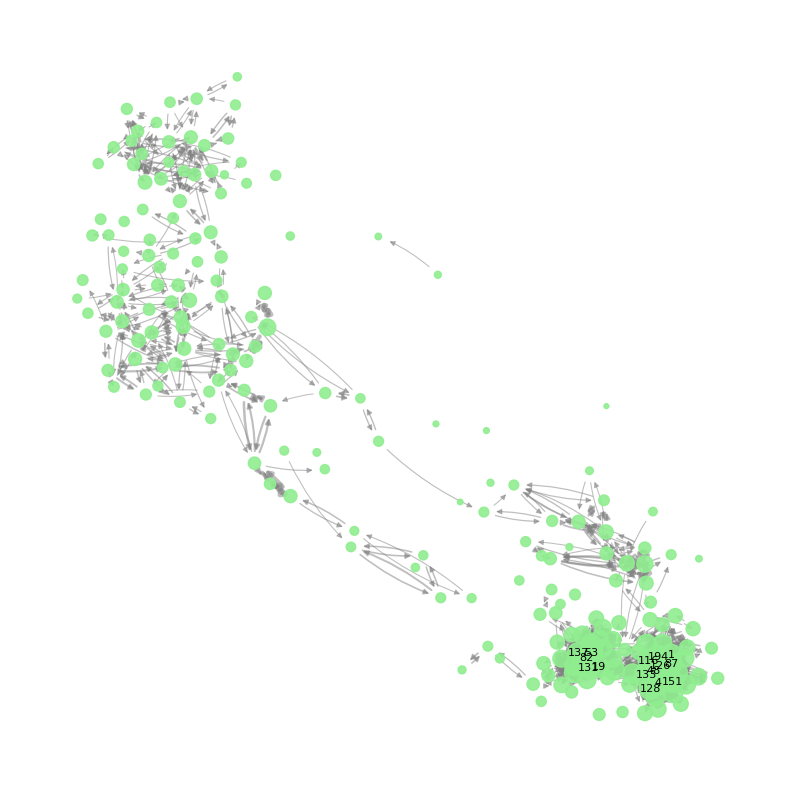

In [ ]:
C = counts.count_matrix.copy()

# Full graph: used only for layout
G_full = nx.from_numpy_array(C, create_using=nx.DiGraph())

pos = nx.spring_layout(
    G_full,
    weight="weight",
    k=0.5,
    seed=0
)

# Sparse graph: used only for visualization
G_vis = nx.DiGraph()
G_vis.add_nodes_from(G_full.nodes())



threshold_counts = 4
for i in range(C.shape[0]):
    for j in range(C.shape[0]):
        if C[i, j] > threshold_counts and i != j:
            G_vis.add_edge(i, j, weight=C[i, j])

node_weights = C.sum(axis=0) + C.sum(axis=1)
node_sizes = 1000 * np.log10(1 + node_weights / node_weights.max())

edge_weights = np.array([d["weight"] for _, _, d in G_vis.edges(data=True)])
edge_widths = 0.2 + 5 * edge_weights / edge_weights.max()

plt.figure(figsize=(10, 10))

nx.draw_networkx_nodes(
    G_vis, pos,
    node_size=node_sizes,
    node_color="lightgreen",
    alpha=0.9
)

nx.draw_networkx_edges(
    G_vis, pos,
    width=edge_widths,
    edge_color="gray",
    alpha=0.5,
    arrows=True,
    arrowsize=8,
    connectionstyle="arc3,rad=0.1"
)

largest = np.argsort(node_weights)[-15:]
labels = {i: str(i) for i in largest}

nx.draw_networkx_labels(
    G_vis, pos,
    labels=labels,
    font_size=8
)

plt.axis("off")
plt.show()

**Comment** nice that the graph looks almost bipartite. Perhaps the two hubs are the folded and unfolded basins? Still too early to say, but encouraging to see.

#### Select largest connected component

A graph induced by the adjacency matrix is called strongly connected if the edges are directed and there is a path from each state i to each state j. It is called weakly connected if the edges are undirected and there is a path from each state 
i to each state j.

We need to identify the **largest strongly connected component** of the graph.

In [65]:
print("Weakly connected sets:", len(counts.connected_sets(directed=False)))
print("Strongly connected sets:", len(counts.connected_sets(directed=True)))

Weakly connected sets: 1
Strongly connected sets: 1


In this case, the graph is already strongly connected: good.

### Estimate the transition matrix  $\quad T_\tau$

Possibilities:

- Maximum Likelihood Estimator or Bayesian
    - if bayesian, which prior
- Detailed balance constraint: yes or no

In [ ]:
estimator = MaximumLikelihoodMSM(
    reversible=True,
    stationary_distribution_constraint=None
)

Lag this model was estimated at:  50


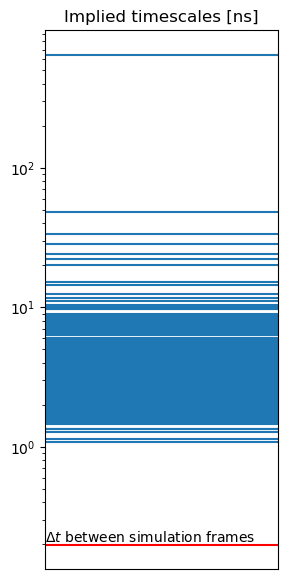

In [92]:
msm = estimator.fit(counts).fetch_model() # instance of class MarkovStateModelCollection
print("Lag this model was estimated at: ", msm.lagtime) # inherited it from the count matrix model, nice!

timescales_ns = msm.timescales()*time_between_frames_mus * 10**3


#################################################################
fig, ax = plt.subplots(figsize = (3, 7))

for time in timescales_ns:
    ax.axhline(time)
ax.set_xticks([])

ax.axhline(time_between_frames_mus * 10**3, color = "red")
ax.text( x = 0, y = time_between_frames_mus * 10**3 + 0.01, s = r"$\Delta t$ between simulation frames")

ax.set_yscale("log", base = 10)
ax.set_title("Implied timescales [ns]")
plt.show()

---
## Validation

1. Implied timescales convergence test
2. autocorrelation test
3. coarse graining into macrostates and Chapman-Kolmogorov test

### Implied timescales convergence test